## **Linear vs. Nonlinear**

The `make_moons` data creation routine in Scikit-Learn produces non-linear data that is useful for understanding the difference between linear and non-linear classifiers.

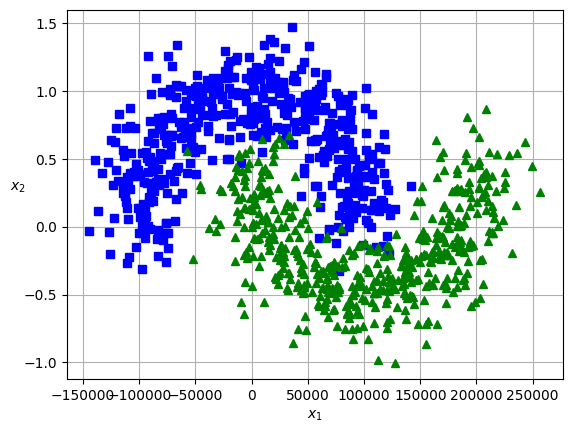

In [ ]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X[:,0] = X[:,0]*100000


def plot_dataset(X, y, axes=None):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    if axes:
        plt.axis(axes)
    plt.grid(True)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

plot_dataset(X, y)

**Exercise 1**

Using a train-test split, run a simple `LogisticRegression` classifier on the above data. Try different solvers. Which works the best?

For more information on `LogisitcRegression` solvers, consult the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = .8, random_state=42)

def run_lr(solver):
    # Initialize the Logistic Regression model with the specified solver
    LR = LogisticRegression(solver=solver, max_iter=1000, tol=1e-3)
    # Fit the model on the training data
    LR.fit(X_train, y_train)
    # Predict the labels for the test set
    y_pred = LR.predict(X_test)
    # Calculate and return the accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Test the solvers and print their accuracy
accuracies = {}
for solver in ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']:
    accuracies[solver] = run_lr(solver)

print(accuracies)

/usr/local/lib/python3.10/dist-packages/scipy/optimize/_linesearch.py:313: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/optimize.py:99: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(


{'lbfgs': 0.86, 'liblinear': 0.655, 'newton-cg': 0.855, 'sag': 0.655, 'saga': 0.655}


**Exercise 2**

Note that the two dimensions have vastly different magnitudes. Modify the above, using a `StandardScaler` and pipeline to transform the data. Does it help?  Do the different solvers have the same relative performance?

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def run_lr(solver):
    # Create a pipeline with a standard scaler and logistic regression
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(solver=solver, max_iter=1000, tol=1e-3))
    ])
    # Fit the model on the training data
    pipe.fit(X_train, y_train)
    # Predict the labels for the test set
    y_pred = pipe.predict(X_test)
    # Calculate and return the accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Test the solvers and print their accuracy
accuracies = {}
for solver in ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']:
    accuracies[solver] = run_lr(solver)

print(accuracies)

{'lbfgs': 0.855, 'liblinear': 0.855, 'newton-cg': 0.855, 'sag': 0.855, 'saga': 0.855}


**Exercise 3**

Try the different following methods to classify your data:

1. KNN (pick the best "nearest neighbors" parameter you can)

2. SVC, linear kernel

3. SVC, poly kernel

4. SVC, rbf kernel

Which performs the best?  Why do you think that is?

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

def evaluate_classifier(clf):
    # Create a pipeline with a standard scaler and the given classifier
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', clf)
    ])
    # Fit the model on the training data
    pipe.fit(X_train, y_train)
    # Predict the labels for the test set
    y_pred = pipe.predict(X_test)
    # Calculate and return the accuracy score
    return accuracy_score(y_test, y_pred)

# Test different classifiers
classifiers = {
    'KNN': None,  # Placeholder for the KNN best parameter search
    'SVC_linear': SVC(kernel='linear'),
    'SVC_poly': SVC(kernel='poly'),
    'SVC_rbf': SVC(kernel='rbf')
}

# Finding the best parameter for KNN
k_range = range(1, 31)
best_k = 1
best_score = 0
for k in k_range:
    score = evaluate_classifier(KNeighborsClassifier(n_neighbors=k))
    if score > best_score:
        best_score = score
        best_k = k
classifiers['KNN'] = KNeighborsClassifier(n_neighbors=best_k)

# Evaluate all classifiers
accuracies = {}
for name, clf in classifiers.items():
    if clf is not None:  # Ensure the classifier has been defined
        accuracies[name] = evaluate_classifier(clf)

print('Best K for KNN:', best_k)
print(accuracies)

Best K for KNN: 9
{'KNN': 0.995, 'SVC_linear': 0.855, 'SVC_poly': 0.85, 'SVC_rbf': 0.98}


**Exercise 4**

In the following, I've set up some code to explore the impact of different parameters and data on an SVC.  As implemented, the current code illustrates how an 'rbf' kernel can overfit the data.  Vary the parameters to examine how different parameters influence performance and overfitting.

1) Try changing the amount of noise in the dataset.  What happens?

2) Try changing the parameter 'gamma.'  What setting seems to avoid overfitting while still performing well.  Have a look at the SVC [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) so you have an understanding of what's going on.

3) Try changing the kernel to a 'poly' kernel, and modify gamma as necessary.  How does this affect performance?

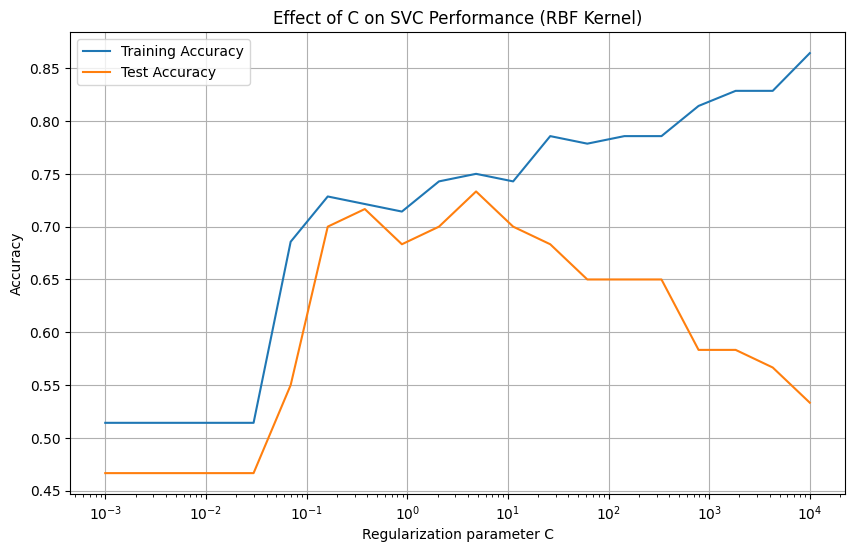

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate a noisy moons dataset
X, y = make_moons(n_samples=200, noise=0.9, random_state=42)

# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Range of C values to explore
C_values = np.logspace(-3, 4, 20)  # From very small to somewhat larger (10^4) C values
train_scores = []
test_scores = []

# Explore the effect of C
for C in C_values:
    clf = SVC(C=C, kernel='rbf', gamma=1)  # Using 'scale' for gamma as an example
    clf.fit(X_train, y_train)

    # Record training and test scores
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

# Plotting
plt.figure(figsize=(10, 6))
plt.semilogx(C_values, train_scores, label='Training Accuracy')
plt.semilogx(C_values, test_scores, label='Test Accuracy')
plt.legend()
plt.xlabel('Regularization parameter C')
plt.ylabel('Accuracy')
plt.title('Effect of C on SVC Performance (RBF Kernel)')
plt.grid(True)
plt.show()